In [1]:
import pandas as pd
from sqlalchemy import create_engine, types
from sqlalchemy import text # to be able to pass string

# 1. Set up connection (update credentials and host!)
from dotenv import dotenv_values

config = dotenv_values() 

# define variables for the login
pg_user = config['POSTGRES_USER']  # align the key label with your .env file !
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']

url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

engine = create_engine(url, echo=False)

# 2. Load data

my_schema = "team_3"

mart_all_data = pd.read_sql(
    f"SELECT * FROM {my_schema}.mart_all_data;",
    engine,
    parse_dates=['transaction_date']
)

# Customer demographic data (for segmentation)
mart_customers = pd.read_sql(
    f"SELECT * FROM {my_schema}.mart_customers;",
    engine
)

In [2]:
mart_all_data.columns

Index(['transaction_date', 'transaction_id', 'customer_id', 'customer_gender',
       'customer_location', 'customer_tenure_months', 'produkt_sku',
       'product_category', 'quantity', 'avg_price', 'delivery_charges',
       'revenue', 'coupon_status', 'discount_pct', 'gst_onsale',
       'daily_offline', 'daily_online', 'transaction_month',
       'transaction_month_str'],
      dtype='object')

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

# Helper functions
def topn(df, n=10):
    return df.head(n)

def print_md(txt):
    print(txt)

# Columns in your data
price_col = 'avg_price'
revenue_col = 'revenue'
product_col = 'produkt_sku'



In [6]:
# ---------- 1) Customer Demographics ----------

unique_customers = mart_all_data['customer_id'].nunique()
location_counts = (
    mart_all_data.groupby('customer_location')['customer_id']
    .nunique()
    .sort_values(ascending=False)
    .rename('unique_customers')
    .reset_index()
)

# Per-customer aggregates
cust_orders = (
    mart_all_data.groupby('customer_id')
    .agg(total_revenue=(revenue_col,'sum'),
         orders=('transaction_id','nunique'),
         customer_location=('customer_location','first'))
    .reset_index()
)
cust_orders['AOV'] = cust_orders['total_revenue'] / cust_orders['orders'].replace(0, np.nan)

# Top locations
location_spend = cust_orders.groupby('customer_location')['total_revenue'].sum().sort_values(ascending=False).reset_index()
location_aov   = cust_orders.groupby('customer_location')['AOV'].mean().sort_values(ascending=False).reset_index()

print_md(f"""
## CUSTOMER DEMOGRAPHICS

- **Unique customers:** **{unique_customers:,}**
- **Top locations by unique customers (top 10):**
""")
print(topn(location_counts, 10))

print_md("\n- **Top locations by total spend (top 10):**")
print(topn(location_spend, 10))

print_md("\n- **Top locations by average order value (AOV) (top 10):**")
print(topn(location_aov, 10))



## CUSTOMER DEMOGRAPHICS

- **Unique customers:** **1,468**
- **Top locations by unique customers (top 10):**

  customer_location  unique_customers
0        California               464
1          Illinois               456
2          New York               324
3        New Jersey               149
4     Washington DC                75

- **Top locations by total spend (top 10):**
  customer_location  total_revenue
0          Illinois     1819011.81
1        California     1615397.39
2          New York     1056559.33
3        New Jersey      452428.09
4     Washington DC      284033.07

- **Top locations by average order value (AOV) (top 10):**
  customer_location         AOV
0     Washington DC  210.542638
1          New York  193.606119
2        New Jersey  191.655340
3          Illinois  187.173256
4        California  182.263861


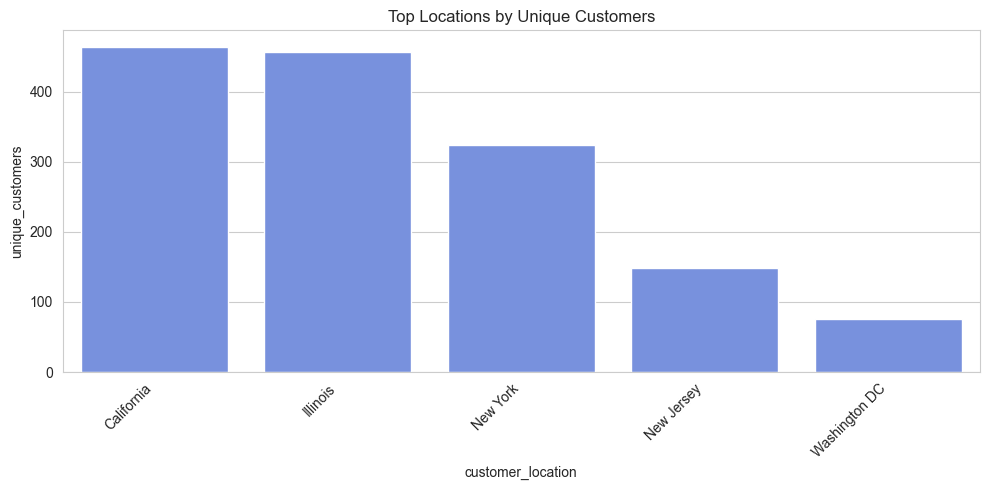

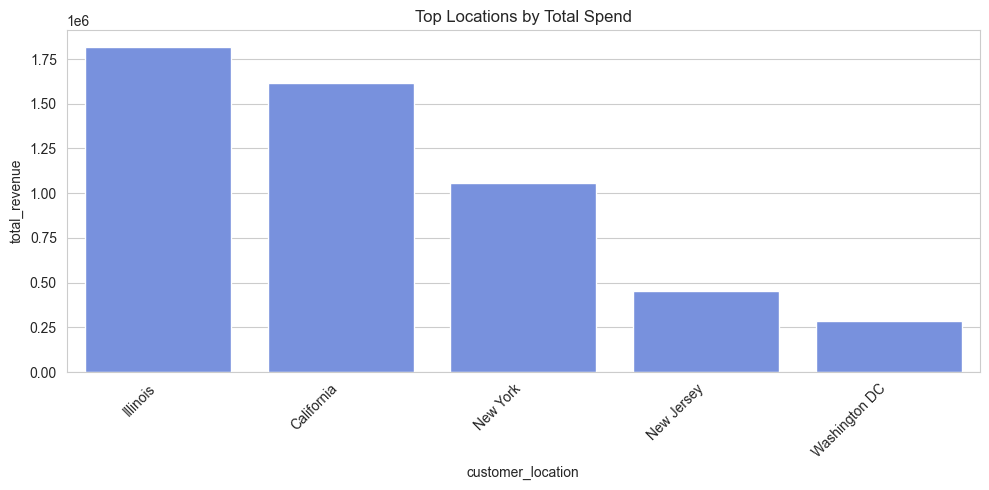

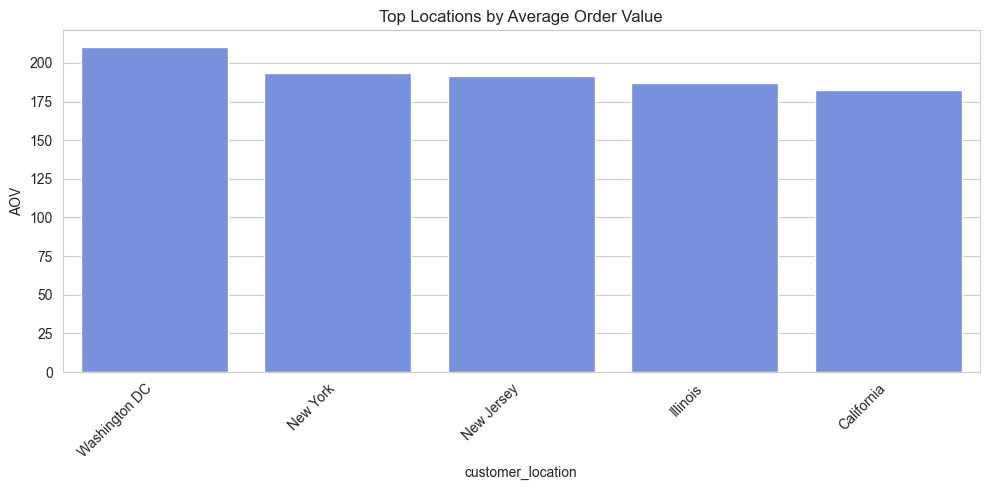

In [20]:
sns.set_style("whitegrid")
sns.set_palette("coolwarm")

plt.figure(figsize=(10,5))
sns.barplot(data=topn(location_counts,10), x='customer_location', y='unique_customers')
plt.title('Top Locations by Unique Customers')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=topn(location_spend,10), x='customer_location', y='total_revenue')
plt.title('Top Locations by Total Spend')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=topn(location_aov,10), x='customer_location', y='AOV')
plt.title('Top Locations by Average Order Value')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()


In [9]:
# ---------- ) Price & Revenue Distribution ----------
price_series = mart_all_data[price_col]
rev_series   = mart_all_data[revenue_col]

desc_price = price_series.describe(percentiles=[.5,.75,.9,.95,.99]).to_frame(price_col)
desc_rev   = rev_series.describe(percentiles=[.5,.75,.9,.95,.99]).to_frame(revenue_col)

print_md("## PRICE & REVENUE DISTRIBUTION\n**Summary statistics (price):**")
print(desc_price)

print_md("\n**Summary statistics (revenue per line/row):**")
print(desc_rev)

print_md(f"""
- **Price skewness:** {price_series.skew():.2f}
- **Revenue skewness:** {rev_series.skew():.2f}
(Positive skew indicates long right tail / high-value outliers.)
""")

## PRICE & REVENUE DISTRIBUTION
**Summary statistics (price):**
          avg_price
count  52924.000000
mean      52.237646
std       64.006882
min        0.390000
50%       16.990000
75%      102.130000
90%      149.000000
95%      151.880000
99%      279.000000
max      355.740000

**Summary statistics (revenue per line/row):**
            revenue
count  52924.000000
mean      98.772385
std      166.441239
min        4.120000
50%       42.890000
75%      129.270000
90%      244.000000
95%      322.500000
99%      570.990000
max    10518.390000

- **Price skewness:** 1.63
- **Revenue skewness:** 18.08
(Positive skew indicates long right tail / high-value outliers.)



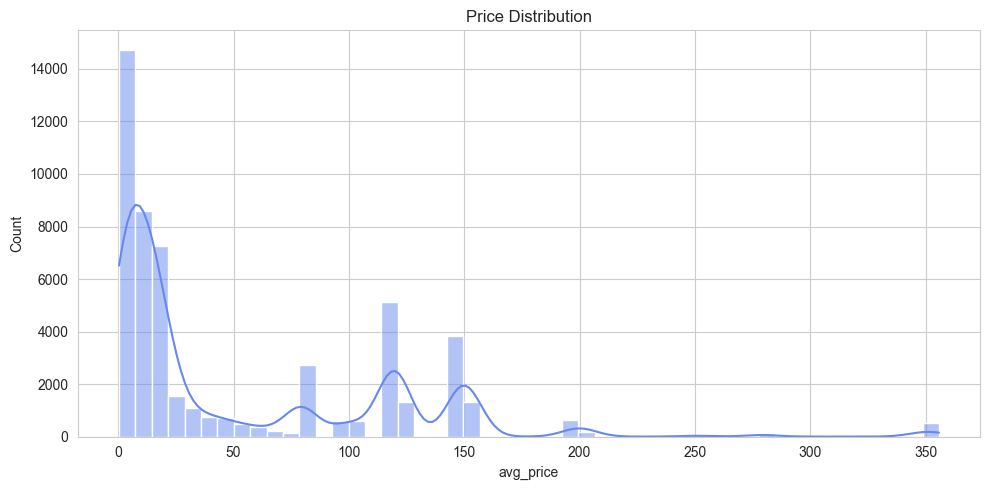

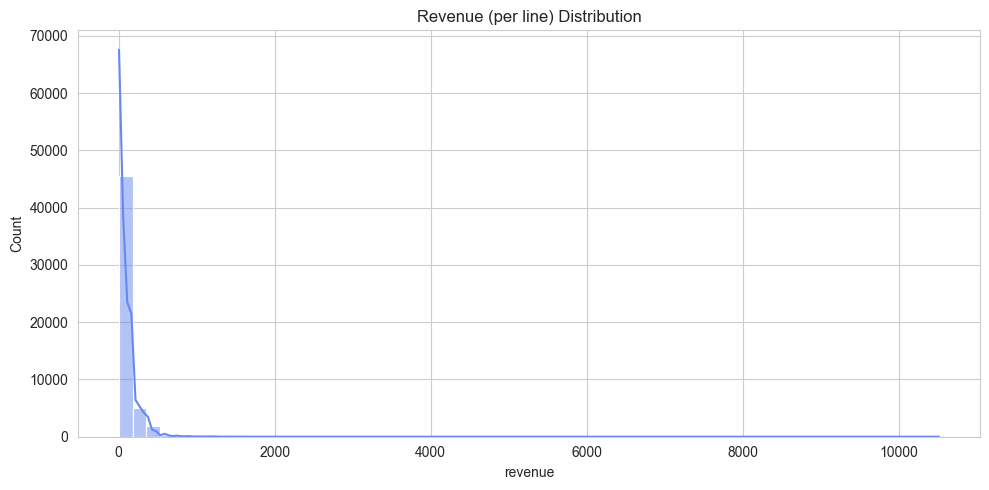

**Highest-priced products (by mean avg_price):**
      produkt_sku   avg_price
0  GGOENEBQ092299  351.287269
1  GGOENEBQ092399  279.472973
2  GGOENEBQ086599  272.892500
3  GGOEGGCX056399  250.107111
4  GGOENEBJ081899  199.940183
5  GGOENEBQ086499  199.916728
6  GGOENEBJ079499  150.981874
7  GGOENEBQ086899  150.350000
8  GGOENEBB081499  150.030253
9  GGOENEBQ081599  149.776500

**Locations by mean/median transaction value (top 10 by mean):**
  customer_location  mean_value  median_value  count
0     Washington DC  103.965253        47.990   2732
1        New Jersey  100.472594        42.000   4503
2        California  100.111390        43.225  16136
3          Illinois   98.966910        43.540  18380
4          New York   94.563620        40.480  11173


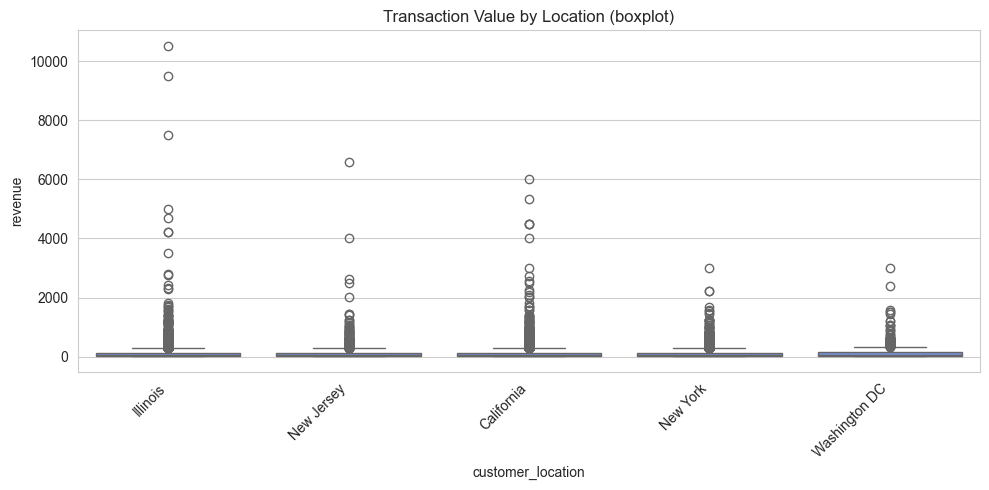

In [27]:
plt.figure(figsize=(10,5))
sns.histplot(price_series.dropna(), bins=50, kde=True)
plt.title('Price Distribution'); plt.xlabel(price_col); plt.tight_layout(); plt.show()

plt.figure(figsize=(10,5))
sns.histplot(rev_series.dropna(), bins=60, kde=True)
plt.title('Revenue (per line) Distribution'); plt.xlabel(revenue_col); plt.tight_layout(); plt.show()

# Highest / lowest priced products (by average price)
prod_price = (
    mart_all_data.groupby(product_col)[price_col]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
print_md("**Highest-priced products (by mean avg_price):**")
print(topn(prod_price, 10))

# Locations with highest median/mean transaction value
loc_txn_value = (
    mart_all_data.groupby('customer_location')[revenue_col]
    .agg(mean_value='mean', median_value='median', count='size')
    .sort_values(by='mean_value', ascending=False)
    .reset_index()
)
print_md("\n**Locations by mean/median transaction value (top 10 by mean):**")
print(topn(loc_txn_value, 10))

plt.figure(figsize=(10,5))
sns.boxplot(data=mart_all_data, x='customer_location', y=revenue_col)
plt.title('Transaction Value by Location (boxplot)')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()


In [22]:
# ---------- 3) Purchasing Behaviour ----------
unique_txn = mart_all_data['transaction_id'].nunique()
print_md(f"## PURCHASING BEHAVIOUR\n- **Unique purchases (transactions):** **{unique_txn:,}**")

# Top customers by total spend
top_cust_by_spend = cust_orders.sort_values('total_revenue', ascending=False)
print_md("\n**Top customers by total spend:**")
print(topn(top_cust_by_spend[['customer_id','customer_location','orders','total_revenue','AOV']], 10))

# Highest AOV customers (require min orders to avoid one-off bias)
min_orders = 2
hi_aov = cust_orders[cust_orders['orders'] >= min_orders].sort_values('AOV', ascending=False)
print_md(f"\n**Customers with highest AOV (min {min_orders} orders):**")
print(topn(hi_aov[['customer_id','customer_location','orders','AOV','total_revenue']], 10))

# Customers with largest order quantities
qty_per_cust = (
    mart_all_data.groupby('customer_id')['quantity']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
print_md("\n**Customers with largest total quantities purchased:**")
print(topn(qty_per_cust, 10))

# Repeat purchase rate
repeat_rate = (cust_orders['orders'] > 1).mean()
print_md(f"\n**Repeat purchase rate:** **{repeat_rate:.2%}**")


## PURCHASING BEHAVIOUR
- **Unique purchases (transactions):** **25,061**

**Top customers by total spend:**
      customer_id customer_location  orders  total_revenue         AOV
118         12748          Illinois     328       83112.26  253.391037
736         15311          Illinois     291       80775.51  277.579072
563         14606          Illinois     289       64045.50  221.610727
643         14911        California     276       56169.82  203.513841
1355        17841        California     263       53896.30  204.928897
1218        17337        California     139       38162.49  274.550288
1358        17850          Illinois     177       37714.02  213.073559
667         15039          Illinois     148       30508.02  206.135270
202         13089        New Jersey     176       30472.73  173.140511
578         14667        California      71       27835.61  392.050845

**Customers with highest AOV (min 2 orders):**
      customer_id customer_location  orders          AOV  tota

## TIME-BASED TRENDS
**Orders by month:**
    transaction_month  orders
0                 1.0    2102
1                 2.0    1664
2                 3.0    1991
3                 4.0    1813
4                 5.0    2034
5                 6.0    1940
6                 7.0    2080
7                 8.0    2414
8                 9.0    1932
9                10.0    2125
10               11.0    2282
11               12.0    2684

**Revenue by month:**
    transaction_month    revenue
0                 1.0  462866.90
1                 2.0  360036.40
2                 3.0  410408.03
3                 4.0  443100.16
4                 5.0  349159.59
5                 6.0  358594.96
6                 7.0  421362.00
7                 8.0  462309.94
8                 9.0  401553.82
9                10.0  455643.16
10               11.0  541254.55
11               12.0  561140.18


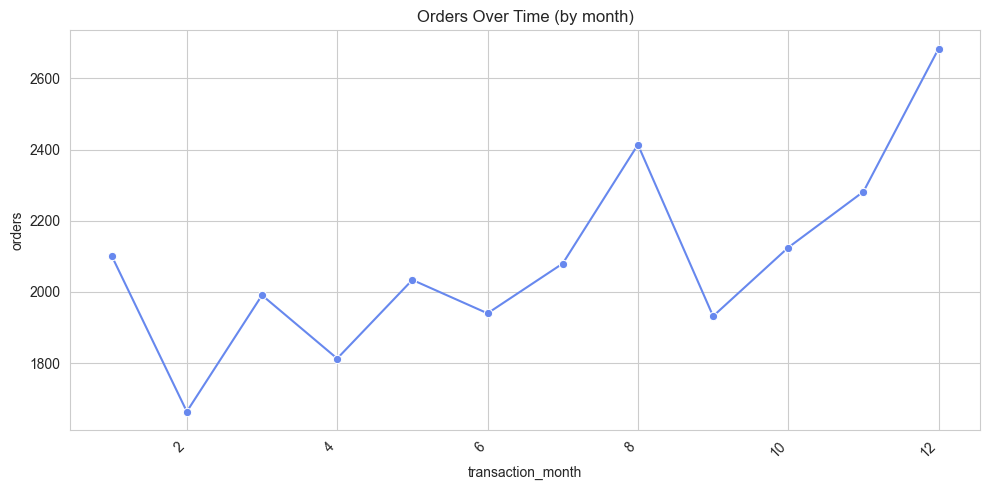

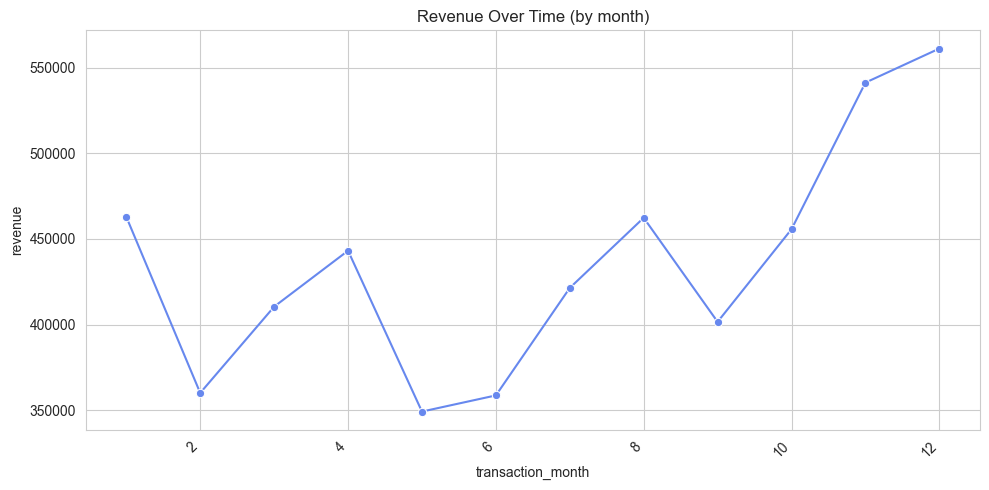

In [23]:
# ---------- 4) Time-based Trends ----------
orders_by_month = (
    mart_all_data.groupby('transaction_month')['transaction_id']
    .nunique()
    .reset_index(name='orders')
)
revenue_by_month = (
    mart_all_data.groupby('transaction_month')[revenue_col]
    .sum()
    .reset_index(name='revenue')
)

print_md("## TIME-BASED TRENDS\n**Orders by month:**")
print(orders_by_month)
print_md("\n**Revenue by month:**")
print(revenue_by_month)

plt.figure(figsize=(10,5))
sns.lineplot(data=orders_by_month, x='transaction_month', y='orders', marker='o')
plt.title('Orders Over Time (by month)'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

plt.figure(figsize=(10,5))
sns.lineplot(data=revenue_by_month, x='transaction_month', y='revenue', marker='o')
plt.title('Revenue Over Time (by month)'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


## INTERESTING INSIGHTS
**Locations with highest median prices (top 10):**
  customer_location  median_price  mean_price  count
0     Washington DC        18.515   55.598712   2732
1        California        16.990   52.363269  16136
2          Illinois        16.990   51.912777  18380
3        New Jersey        16.990   53.146298   4503
4          New York        16.790   51.402594  11173

**High spenders with few unique products (top 10):**
      customer_id customer_location  orders  unique_products  total_revenue  \
118         12748          Illinois     328              308       83112.26   
736         15311          Illinois     291              237       80775.51   
563         14606          Illinois     289              286       64045.50   
643         14911        California     276              209       56169.82   
1355        17841        California     263              267       53896.30   
1218        17337        California     139               69       38162.49   


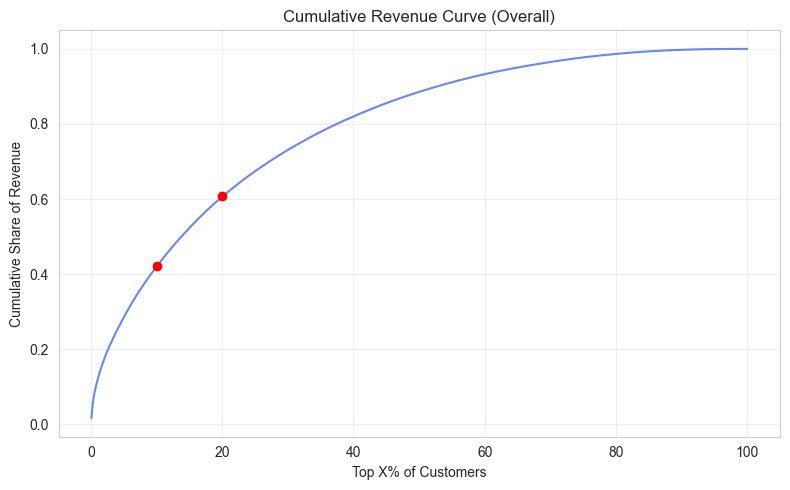

In [28]:
# ---------- 5) Interesting Insights ----------
# (A) Locations with extreme prices
loc_price_stats = (
    mart_all_data.groupby('customer_location')[price_col]
    .agg(median_price='median', mean_price='mean', count='size')
    .sort_values('median_price', ascending=False)
    .reset_index()
)
print_md("## INTERESTING INSIGHTS\n**Locations with highest median prices (top 10):**")
print(topn(loc_price_stats, 10))

# (B) High spenders with low product variety
cust_product_count = (
    mart_all_data.groupby('customer_id')[product_col]
    .nunique()
    .reset_index(name='unique_products')
)
merged = cust_orders.merge(cust_product_count, on='customer_id', how='left')
notable = merged.sort_values(['total_revenue','unique_products'], ascending=[False, True])

print_md("\n**High spenders with few unique products (top 10):**")
print(topn(notable[['customer_id','customer_location','orders','unique_products','total_revenue','AOV']], 10))

# (C) Whale analysis: % revenue from top 10% and 20% customers
cust_spend = cust_orders[['customer_id','total_revenue']].sort_values('total_revenue', ascending=False).reset_index(drop=True)
cum_share = cust_spend['total_revenue'].cumsum() / cust_spend['total_revenue'].sum()
pct = (np.arange(1, len(cust_spend)+1) / len(cust_spend))

top10_share = cum_share.iloc[int(np.ceil(0.10 * len(cust_spend)))-1]
top20_share = cum_share.iloc[int(np.ceil(0.20 * len(cust_spend)))-1]

print_md(f"""
**Whale analysis (overall):**
- Revenue share from **top 10%** customers: **{top10_share*100:.1f}%**
- Revenue share from **top 20%** customers: **{top20_share*100:.1f}%**
""")

plt.figure(figsize=(8,5))
plt.plot(pct*100, cum_share, label='Cumulative Revenue Share')
plt.scatter([10,20], [top10_share, top20_share], color='red', zorder=5)
plt.title('Cumulative Revenue Curve (Overall)')
plt.xlabel('Top X% of Customers'); plt.ylabel('Cumulative Share of Revenue')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()



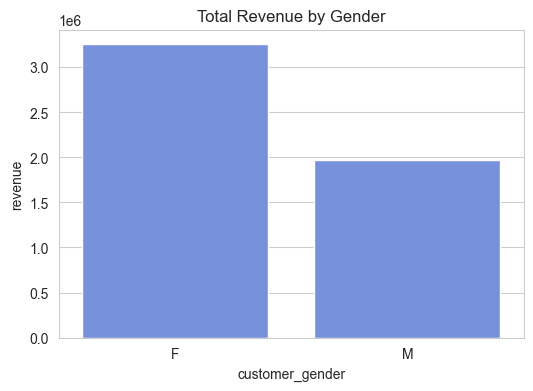

In [25]:
# Gender Spend Analysis
gender_spend = mart_all_data.groupby('customer_gender')[revenue_col].sum().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(data=gender_spend, x='customer_gender', y=revenue_col)
plt.title('Total Revenue by Gender')
plt.show()



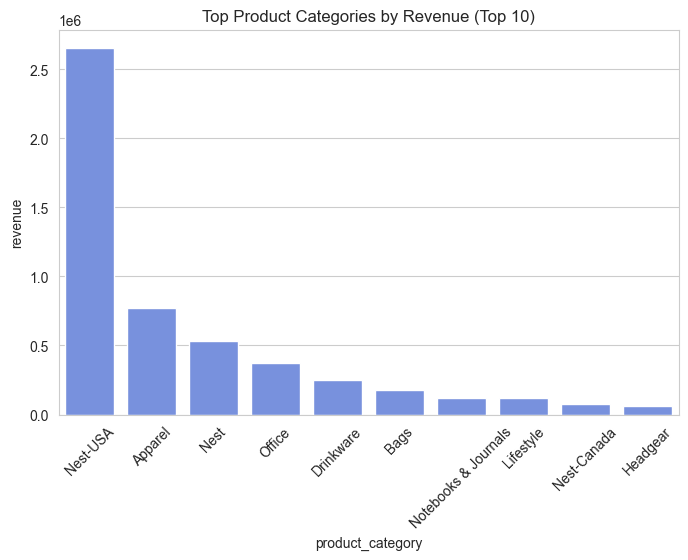

In [26]:
# Product Category Leaders
category_spend = mart_all_data.groupby('product_category')[revenue_col].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(8,5))
sns.barplot(data=category_spend.head(10), x='product_category', y=revenue_col)
plt.title('Top Product Categories by Revenue (Top 10)')
plt.xticks(rotation=45)
plt.show()